## Imports

In [1]:
import wandb
import logging
from tqdm import tqdm
from wandb.sdk.wandb_run import Run
import numpy as np
import pandas as pd
import plotly.express as px
import numpy as np
import plotly.graph_objs as go
import seaborn as sns
import matplotlib.pyplot as plt
from nn_core.common import PROJECT_ROOT
import json

/media/donato/Extra-storage/Code/model-merging/mass/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/media/donato/Extra-storage/Code/model-merging/mass/.venv/lib/python3.11/site-packages/transformers/utils/hub.py:124: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(


## Configuration

In [2]:
from mass.utils.plots import Palette

plt.rcParams.update(
    {
        "text.usetex": True,
        "font.family": "serif",
        "axes.titlesize": 24,        # Larger axes/title fonts
        "axes.labelsize": 28,
        "xtick.labelsize": 28,
        "ytick.labelsize": 28,
        "legend.fontsize": 24,
    }
)
sns.set_context("talk")

cmap_name = "coolwarm_r"

palette = Palette(f"{PROJECT_ROOT}/misc/palette.json", map_path=f"{PROJECT_ROOT}/misc/palette_map.json")
palette

Project not installed in the current env, activate the correct env or install it with:
	pip install -e .


{'blue': '#335c67',
 'white': '#fff3b0',
 'yellow': '#e09f3e',
 'red': '#9e2a2b',
 'dark red': '#540b0e',
 'green': '#81b29a'}

## Get runs

In [3]:
api = wandb.Api()
entity, project = "gladia", "mass"  # set to your entity and project

In [4]:
def get_runs(entity, project, positive_tags, negative_tags):
    filters_pos_tags = {"$and": [{"tags": {"$eq": pos_tag}} for pos_tag in positive_tags]}
    filters_neg_tags = {}

    print(filters_pos_tags)
    filters = {**filters_pos_tags, **filters_neg_tags}
    runs = api.runs(entity + "/" + project, filters=filters)

    print(f"There are {len(runs)} runs respecting these conditions.")
    return runs

In [5]:
datasets =  ['Cars', 'DTD', 'EuroSAT', 'GTSRB', 'MNIST', 'RESISC45', 'SUN397', 'SVHN', 'CIFAR100', 'STL10', 'Flowers102', 'OxfordIIITPet', 'PCAM', 'FER2013', 'EMNIST', 'CIFAR10', 'Food101', 'FashionMNIST', 'RenderedSST2', 'KMNIST']

## Sweeping over Top-K 

In [6]:
runs = get_runs(entity, project, positive_tags=['sweep_over_topk', 'grid_search', 'n20', 'hyper_params', 'sweep_over_threshold'], negative_tags=[])

{'$and': [{'tags': {'$eq': 'sweep_over_topk'}}, {'tags': {'$eq': 'grid_search'}}, {'tags': {'$eq': 'n20'}}, {'tags': {'$eq': 'hyper_params'}}, {'tags': {'$eq': 'sweep_over_threshold'}}]}
There are 42 runs respecting these conditions.


In [7]:
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt


records = []
for i, run in enumerate(runs):
    col_name = "normalized_acc/test/avg"
    try:
        norm_acc  = run.history(keys=[col_name]).iloc[-1][col_name]
        top_k      = run.config['nn/module/router/max_num_tasks_to_select']
        threshold  = run.config['nn/module/router/threshold']
        records.append({
            'top_k':     top_k,
            'threshold': threshold,
            'norm_acc':  norm_acc
        })
    except Exception as e:
        print(f"[WARN] Run {i} '{run.name}' skipped: {e}")
        continue



[WARN] Run 0 'celestial-sky-3437' skipped: single positional indexer is out-of-bounds
[WARN] Run 1 'genial-shadow-3436' skipped: single positional indexer is out-of-bounds
[WARN] Run 2 'azure-capybara-3435' skipped: single positional indexer is out-of-bounds
[WARN] Run 3 'glowing-music-3433' skipped: single positional indexer is out-of-bounds
[WARN] Run 4 'vibrant-haze-3432' skipped: single positional indexer is out-of-bounds
[WARN] Run 25 'kind-cosmos-3396' skipped: single positional indexer is out-of-bounds


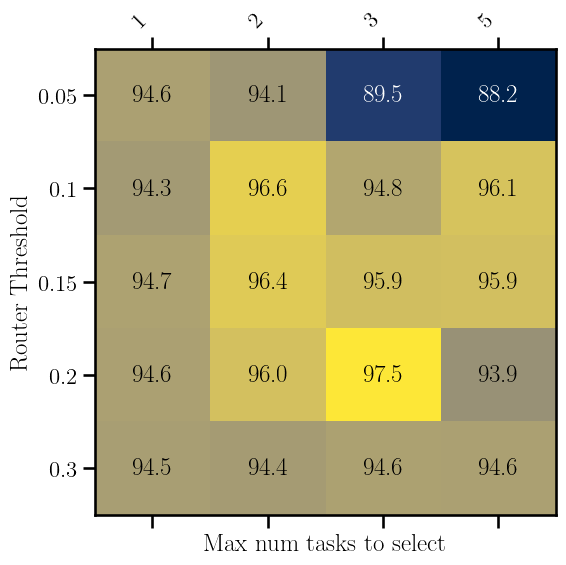

In [8]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

thresholds = sorted({r['threshold'] for r in records})
top_ks     = sorted({r['top_k']    for r in records})


# only keep thresholds and top_ks for thresholds <= 0.3
thresholds = thresholds[:5]
top_ks     = top_ks[:4]


acc_dict   = {(r['threshold'], r['top_k']): r['norm_acc'] for r in records}
acc_matrix = np.array([[100 * acc_dict.get((thr, k), np.nan) for k in top_ks]
                       for thr in thresholds])

fig, ax = plt.subplots(figsize=(6, 6))
cax = ax.matshow(acc_matrix, cmap='cividis', aspect='auto')

# Disattivo ogni griglia sottostante
ax.grid(False)
# Assicuro che le linee degli assi siano visibili
ax.set_frame_on(True)

ax.set_xticks(np.arange(len(top_ks)))
ax.set_xticklabels(top_ks, rotation=45, ha='right')
ax.set_yticks(np.arange(len(thresholds)))
ax.set_yticklabels(thresholds)
ax.set_xlabel('Max num tasks to select')
ax.set_ylabel('Router Threshold')

vmin, vmax = np.nanmin(acc_matrix), np.nanmax(acc_matrix)
mid = (vmin + vmax) / 2
for (i, j), val in np.ndenumerate(acc_matrix):
    if not np.isnan(val):
        color = 'black' if val > mid else 'white'
        ax.text(j, i, f'{val:.1f}', ha='center', va='center', color=color)

# fig.colorbar(cax, label='Normalized Accuracy')
plt.tight_layout()

plt.savefig(f"sweep.pdf", bbox_inches='tight')
plt.show()


### Sweeping over similarity threshold

In [9]:
runs = get_runs(entity, project, positive_tags=['final_sweep'], negative_tags=[])

{'$and': [{'tags': {'$eq': 'final_sweep'}}]}
There are 8 runs respecting these conditions.


In [10]:
run_by_model = {}

sim_results = {}

for run in tqdm(runs):

    try:
        col_name = f"normalized_acc/test/avg"
        norm_acc = run.history(keys=[col_name]).iloc[-1][col_name]

        top_k = run.config['similarity_threshold']

        sim_results[top_k] = norm_acc
    
    except:
        print(f"Run {run.id} does not have the expected column {col_name}.")
        continue

100%|██████████| 8/8 [00:02<00:00,  3.15it/s]


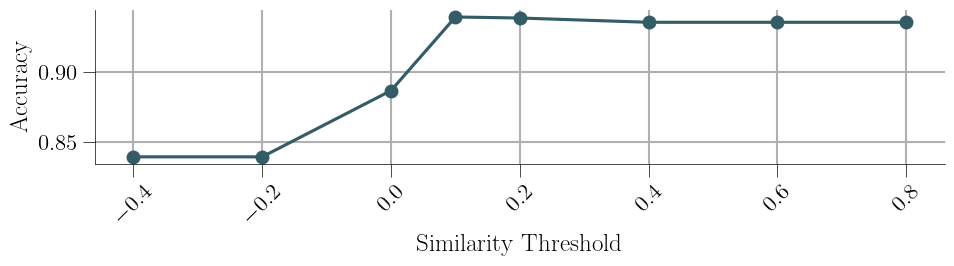

In [11]:
plt.figure(figsize=(10, 3))
plt.plot(sim_results.keys(), sim_results.values(), marker='o', color=palette["blue"], label="Top-K Accuracy")
plt.xlabel("Similarity Threshold")
plt.ylabel("Accuracy")

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['left'].set_linewidth(0.5)
plt.gca().spines['bottom'].set_linewidth(0.5)
plt.gca().xaxis.set_tick_params(width=0.5)
plt.gca().yaxis.set_tick_params(width=0.5)
plt.xticks(rotation=45)
plt.grid()
plt.tight_layout()

plt.savefig(f"sweep_sim.pdf", bbox_inches='tight')

plt.show()
